# 🔍 Credit Card Fraud Detection

## Project Outline

| Phase | Description |
|-------|-------------|
| 1. Problem Definition | What we're solving and why |
| 2. Data Collection | Dataset from Kaggle (284,807 transactions) |
| 3. Data Cleaning | Handling missing values, fixing data types |
| 4. EDA | Understanding data, visualizing fraud vs legit |
| 5. Feature Engineering | Scaling, new features, handling imbalance (SMOTE) |
| 6. Model Building | Using Machine Learning — Logistic Regression |
| 7. Model Testing | Testing model on unseen data, train/test split |
| 8. Evaluation | Precision, Recall, F1, ROC-AUC |
| 9. Conclusion | Best model, ethical considerations |

**Dataset:** [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Target:** Predict fraudulent transactions (Class: 0 = Legit, 1 = Fraud)

## Phase 1 — Problem Definition

Credit Card Fraud Detection is a binary classification problem where we predict 
whether a transaction is fraudulent (1) or legitimate (0).

Credit card fraud is a major financial threat causing billions of dollars in losses 
annually. Detecting fraud manually is impossible due to the sheer volume of 
transactions happening every second. This is where Machine Learning helps and can 
automatically detect suspicious patterns in transaction data.

The dataset is highly imbalanced -only 0.17% of transactions are fraud. This means 
a model that predicts everything as legitimate would still be 99.83% accurate, which 
is misleading. This is why we focus on Precision, Recall and F1 Score rather than 
plain accuracy.

Our goal is to build a Logistic Regression model that can correctly identify 
fraudulent transactions while minimizing false alarms.

In [32]:
# numpy - numerical and mathematical computations
import numpy as np

#data loading and manipulation
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#  machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

# SMOTE - handling imbalanced data
from imblearn.over_sampling import SMOTE

## Phase 2 — Data Collection

The dataset is sourced from Kaggle — Credit Card Fraud Detection.
It contains 284,807 transactions made by European cardholders in September 2013.
Published by: Machine Learning Group, (ULB).

In [3]:
# loading the dataset
df = pd.read_csv('data/creditcard.csv')

# data's characterstics
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Phase 3 — Data Cleaning
Checking for missing values, duplicate rows and correct data types.

In [4]:
print("Missing Values:\n", df.isnull().sum())
# for missing values use mean for evenly distributed numerical data ,median for noticable outliers and mode for strings
# if missing valued rows is < 5% ,remove the row using df.dropna()
print("\nDuplicate Rows:", df.duplicated().sum())
# to remove duplicates using df.drop_duplicates()
print("\nData Types:\n",  all(df.dtypes != 'object'))
# use type casting for primitive data types , methods such as lower, strip , replace for typos ,toDate for dates

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate Rows: 1081

Data Types:
 True


In [5]:
df = df.drop_duplicates()
print("Duplicates removed! New shape:", df.shape)

Duplicates removed! New shape: (283726, 31)


### Data Cleaning Results

- Missing Values: 0 — No missing values found, no action needed.
- Duplicate Rows: 1081 — Duplicates found and removed. New shape: (283726, 31)
- Data Types: All columns are numerical (float64/int64), no text columns found.

If any column had string/text data type, we would have used One Hot Encoding to 
convert them into numerical columns since Machine Learning models can only work 
with numbers.

Dataset is now clean and ready for Exploratory Data Analysis.

## Phase 4 — Exploratory Data Analysis (EDA)

EDA is the process of understanding our data before building any model.
We analyze the distribution of values, spot patterns and visualize relationships 
between variables.

In this phase we will check the statistical summary, visualize the class imbalance 
between fraud and legitimate transactions, and understand how Amount and Time 
are distributed across the dataset.

In [6]:
df.describe()
# checking statstics of each attributes  

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [7]:
df.info()
# information about dataset such as data types ,not null count and memory usage

<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-null  f

In [8]:
# checking occuuence of of fraud vs legitimate transactions
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:", round(df['Class'].mean() * 100, 2), "%")

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud Percentage: 0.17 %


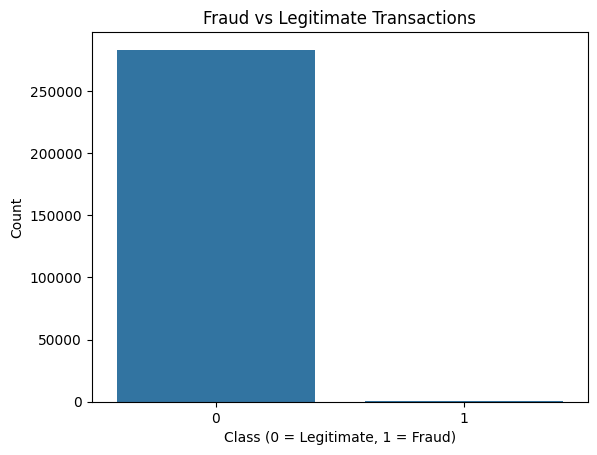

In [9]:
 # visualizing class imbalance
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

### Class Imbalance

The dataset is highly imbalanced:
- Legitimate transactions (Class 0): 99.83%
- Fraudulent transactions (Class 1): 0.17%

This means for every 1 fraud case there are approximately 578 legitimate transactions.
If not addressed, the model will only learn to predict everything as legitimate.

- Non fraud cases will be correctly predicted most of the time
- Only fraud cases will suffer — they get misclassified as legitimate

Missing a fraud case (False Negative) is far more dangerous than wrongly flagging 
a legitimate transaction (False Positive) because undetected fraud leads to direct 
financial loss whereas a wrongly flagged transaction can simply be verified manually.

We will handle this imbalance in the Feature Engineering phase using SMOTE.

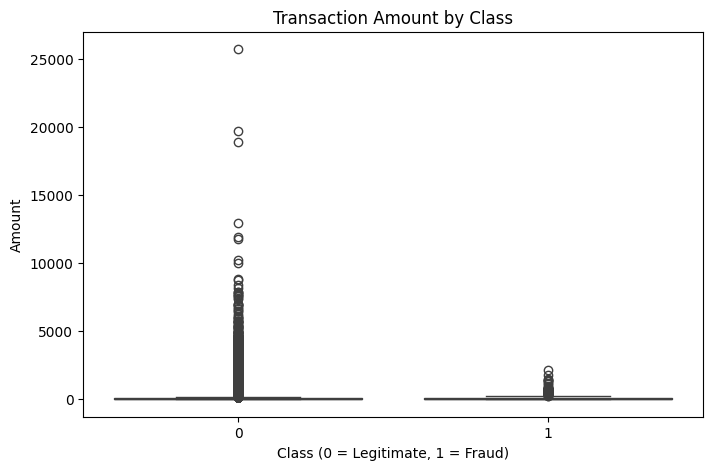

In [10]:
# boxbot to analyze the relationship between class(fraud or real) and amount
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Amount')
plt.show()

### Boxplot Interpretation — Amount by Class

Both legitimate and fraudulent transactions have median amounts close to 0,
meaning most transactions are small regardless of class.

However legitimate transactions have outliers reaching up to 25,000 while
fraud transactions max out around 1,500. This suggests fraudsters deliberately
keep transaction amounts small to avoid detection.

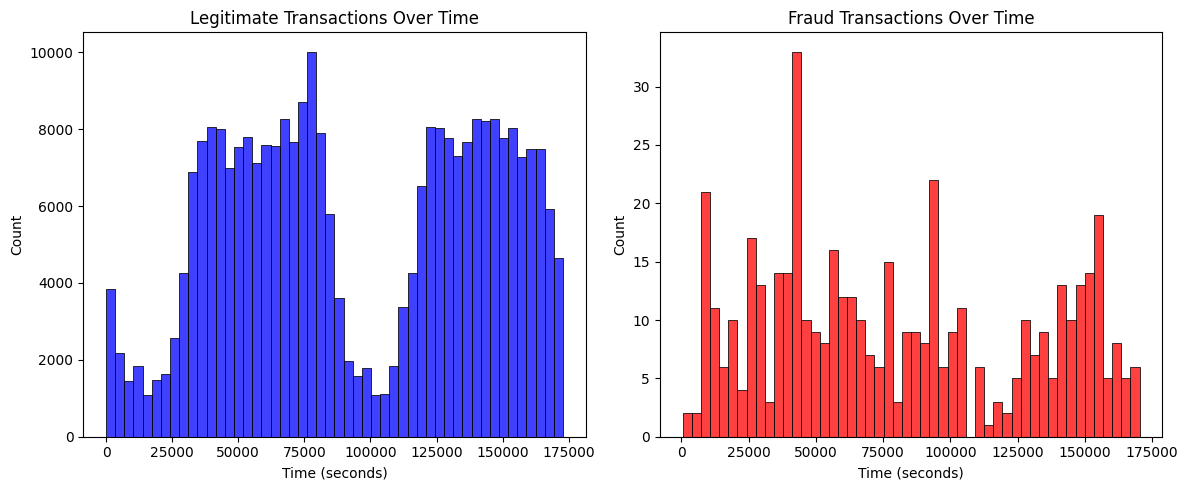

In [11]:
# to analyze trnsaction over time
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df[df['Class']==0]['Time'], bins=50, color='blue', ax=axes[0])
axes[0].set_title('Legitimate Transactions Over Time')
axes[0].set_xlabel('Time (seconds)')

sns.histplot(df[df['Class']==1]['Time'], bins=50, color='red', ax=axes[1])
axes[1].set_title('Fraud Transactions Over Time')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

### Time Distribution Interpretation

Legitimate transactions show a clear two peak pattern representing two days 
of data with a nighttime dip in between — matching normal human behavior.

Fraud transactions spike heavily at the start and remain active throughout 
without following the day/night pattern. This suggests fraud occurs 
disproportionately during odd hours when victims are less vigilant.

## Phase 5 — Feature Engineering

Feature Engineering is the process of transforming raw data into meaningful 
features that improve model performance.

V1-V28 are already PCA transformed with small values, but Amount and Time 
are on a completely different scale (Amount: 0-25000, Time: 0-175000). 
ML models can get confused by large numbers and give more importance to these 
columns just because of their size — not because they are actually more important.

In this phase we will:
- Scale Amount and Time columns to match the range of V1-V28
- Handle class imbalance using SMOTE

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# scaling amount to match PCA features
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
# scaling time to match PCA features
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time columns
df = df.drop(['Amount', 'Time'], axis=1)

print("Scaling done! New shape:", df.shape)
print(df.head())

Scaling done! New shape: (283726, 31)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V2

### Handling Class Imbalance using SMOTE

The dataset has a severe class imbalance with only 0.17% fraud cases.
Simply training a model on this data would result in a biased model that
ignores fraud cases entirely.

To fix this we use SMOTE — Synthetic Minority Oversampling Technique.
Instead of simply copying existing fraud cases, SMOTE creates brand new 
synthetic fraud samples by interpolating between existing fraud cases.
SMOTE uses the K-Nearest Neighbors (KNN) algorithm to find the k closest 
fraud transactions to each existing fraud case, then creates new synthetic 
samples along the line between them. This makes the dataset balanced without 
just repeating the same data.

Why not other techniques:

- Random Oversampling: Simply copies existing fraud rows repeatedly.
  This causes overfitting as the model just memorizes the same examples.

- Random Undersampling: Removes legitimate transactions to balance the data.
  This causes data loss — we lose valuable information from 280,000 transactions.

- SMOTE: Creates new synthetic fraud samples using KNN instead of copying or deleting.
  This balances the dataset without overfitting or losing data. 
  This is why SMOTE is the industry standard for imbalanced classification.

In [13]:

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("Before SMOTE:")
print("Legitimate:", y.value_counts()[0])
print("Fraud:", y.value_counts()[1])

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print("Legitimate:", y_resampled.value_counts()[0])
print("Fraud:", y_resampled.value_counts()[1])

Before SMOTE:
Legitimate: 283253
Fraud: 473

After SMOTE:
Legitimate: 283253
Fraud: 283253


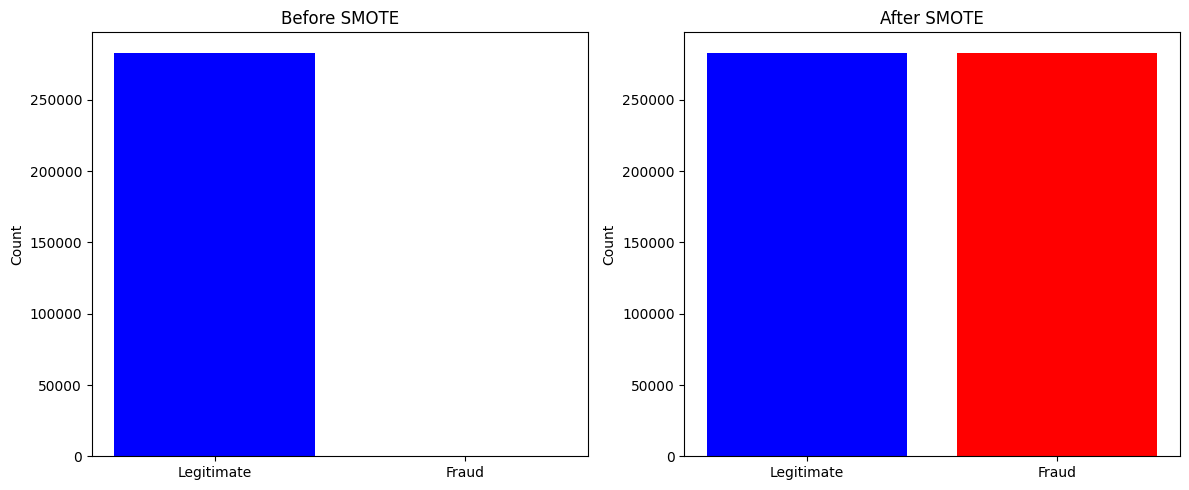

In [14]:
# results after using SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))
# Before SMOTE
axes[0].bar(['Legitimate', 'Fraud'], [y.value_counts()[0], y.value_counts()[1]], color=['blue', 'red'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

# After SMOTE
axes[1].bar(['Legitimate', 'Fraud'], [y_resampled.value_counts()[0], y_resampled.value_counts()[1]], color=['blue', 'red'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Phase 6 — Model Building

Machine Learning models learn patterns from data to make predictions.
In this phase we train a Logistic Regression model on our balanced dataset
to classify transactions as fraudulent or legitimate.

### Step 1 — Train/Test Split

Before training the model we split the dataset into two parts:

- Training set (80%): The model learns patterns from this data
- Testing set (20%): The model is evaluated on this unseen data

This split is important because if we test on the same data we trained on,
the model will simply memorize the answers and perform artificially well.
Testing on unseen data gives us a true measure of how well the model 
will perform in the real world.

We use random_state=42 to ensure the split is always the same,
making our results reproducible.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (453204, 30)
Testing size: (113302, 30)


### Step 2 — Training Logistic Regression Model

Logistic Regression is a classification algorithm that predicts the 
probability of a transaction being fraudulent or legitimate.

Despite its name, Logistic Regression is used for classification not regression.

### How it works:

Step 1 — Linear Model:
First it calculates a weighted sum of all input features:

z = (w1 × V1) + (w2 × V2) + ... + (w30 × Amount_scaled) + bias

Where weights (w1, w2...) represent how important each feature is for 
detecting fraud. Bias is the model's default opinion before looking at 
any features. Both weights and bias are randomly initialized and 
automatically learned during training by iteratively adjusting themselves 
to minimize prediction error.

The output z of this linear model can range from -infinity to +infinity
which cannot be used directly as a probability.

Step 2 — Sigmoid Function:
To convert z into a probability between 0 and 1, we pass it through 
the Sigmoid function:

σ(z) = 1 / (1 + e^(-z))

The exponential term e^(-z) ensures that:
- Very large positive z → e^(-z) approaches 0 → output approaches 1
- Very large negative z → e^(-z) approaches infinity → output approaches 0
- z = 0 → output = exactly 0.5

This maps any value from -infinity to +infinity into a clean 0 to 1 range,
making it usable as a probability.

Step 3 — Classification:
- Probability > 0.5 → Predicted as Fraud (1)
- Probability < 0.5 → Predicted as Legitimate (0)

The threshold of 0.5 is the default but can be adjusted. In fraud detection,
missing a real fraud (False Negative) is more dangerous than a false alarm 
(False Positive). So in real world a lower threshold like 0.3 would make 
more sense to catch more fraud cases even at the cost of more false alarms.

### Why Logistic Regression over other alternatives:

Other binary classification algorithms include:

- Decision Tree: Splits data into rules like "if Amount > 1000 then fraud".
  Simple to understand but tends to overfit — memorizes training data too well
  and performs poorly on new data.

- Random Forest: Combines hundreds of Decision Trees for better accuracy.
  More powerful than Logistic Regression but acts as a black box —
  hard to explain why it made a specific decision.

- Support Vector Machine (SVM): Finds the best boundary line between fraud 
  and legitimate transactions. Works well but is very slow on large datasets
  like ours with 500,000+ rows after SMOTE.

- Neural Networks: Very powerful but requires massive data and computing power.
  Also extremely hard to interpret and explain.

Logistic Regression is chosen because:
- Simple and interpretable — we can see exactly which features influence fraud
- Fast to train even on large datasets
- Outputs a probability score — useful for adjusting threshold
- Strong baseline model — if it performs well, no need for complex models
- Easy to explain to non technical stakeholders like bank managers

In [16]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


## Phase 7 — Model Testing

Now we test the model on unseen data (20% test set) to evaluate
how well it performs on transactions it has never seen before.

During training the model learned patterns from 80% of the data.
Now we feed it the remaining 20% where we already know the correct 
answers (fraud or legitimate) but the model has never seen them.

We compare the model's predictions against the actual answers to 
measure how well it has learned to detect fraud. This gives us a 
realistic picture of how the model would perform in the real world
where it encounters completely new transactions every day.

In [26]:
# make predictions on test data
y_pred = model.predict(X_test)
print("Predictions done!")
print("Sample predictions:", y_pred[:10])
print("Actual values:     ",y_test.values[:10])
print(type(y_test))

Predictions done!
Sample predictions: [1 0 0 1 0 1 1 0 0 1]
Actual values:      [1 0 0 1 0 1 1 1 0 1]
<class 'pandas.Series'>


## Phase 8 — Model Evaluation

After training the model we need to measure how well it performs.
Evaluation tells us if the model is actually learning fraud patterns
or just making lucky guesses.

Confusion Matrix: Shows how many transactions were correctly and incorrectly 
classified — breaking down into True Positives, True Negatives, 
False Positives and False Negatives.

Accuracy: The percentage of correct predictions. Valid here because 
we balanced the dataset using SMOTE before training.

Precision: Out of all transactions predicted as fraud, how many were 
actually fraud? High precision means fewer false alarms.

Recall: Out of all actual fraud transactions, how many did the model 
correctly catch? High recall means fewer missed frauds.

In fraud detection Recall is more critical than Precision because 
missing a real fraud (low Recall) causes direct financial loss whereas 
a false alarm (low Precision) can simply be verified manually.

F1 Score: The harmonic mean of Precision and Recall — gives a single 
number that balances both metrics for overall model performance.

In [33]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 94.53 %


In [34]:
# precision, recall and f1 Score
print(classification_report(y_test, y_pred, 
      target_names=['Legitimate', 'Fraud']))

              precision    recall  f1-score   support

  Legitimate       0.92      0.97      0.95     56463
       Fraud       0.97      0.92      0.94     56839

    accuracy                           0.95    113302
   macro avg       0.95      0.95      0.95    113302
weighted avg       0.95      0.95      0.95    113302



### Evaluation Results

Accuracy: 94.53% — The model correctly classified 94.53% of all transactions.
This is a strong result especially since the dataset was balanced using SMOTE.

Precision:
- Legitimate: 0.92 — 92% of transactions predicted as legitimate were actually legitimate
- Fraud: 0.97 — 97% of transactions predicted as fraud were actually fraud
  High fraud precision means very few false alarms.

Recall:
- Legitimate: 0.97 — 97% of actual legitimate transactions were correctly identified
- Fraud: 0.92 — 92% of actual fraud transactions were correctly caught
  This means the model missed 8% of real fraud cases.

F1 Score: 0.94 for both classes — strong balance between Precision and Recall.

Key Insight: Fraud Precision (0.97) is higher than Fraud Recall (0.92).
This means the model is better at avoiding false alarms than catching all fraud.
However in fraud detection our priority should be high Recall — catching every 
possible fraud even at the cost of some false alarms.

In industrial practice, Recall can be improved by lowering the classification 
threshold below 0.5. By default the model predicts fraud only when probability 
is above 0.5. Lowering it to say 0.3 means the model flags a transaction as 
fraud when it is only 30% sure — casting a wider net and catching more fraud 
cases that would have been missed at 0.5, at the cost of slightly more false alarms.

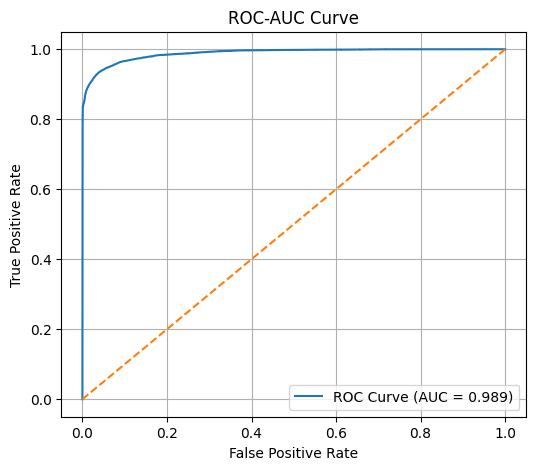

In [39]:
# probability predictions
y_prob = model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.grid()
plt.show()

X-axis (False Positive Rate – FPR):
The proportion of legitimate transactions that are incorrectly classified as fraud.

Y-axis (True Positive Rate – TPR / Recall):
The proportion of actual fraudulent transactions that the model correctly detects.

Dashed Diagonal Line:
Represents a random classifier. A model performing along this line has no predictive ability.

Interpretation of the Curve

The blue curve represents the performance of your model at different classification thresholds.

Since the curve stays close to the top-left corner, it indicates that the model achieves high true positive rates while maintaining low false positive rates.

AUC Score

The Area Under the Curve (AUC) = 0.989.

An AUC value ranges from 0 to 1:

0.5 → Random guessing

0.7–0.8 → Acceptable performance

0.8–0.9 → Good performance

0.9–1.0 → Excellent performance

An AUC of 0.989 indicates that the model is extremely effective at distinguishing between fraudulent and legitimate transactions.